In [1]:
import torch
from torchvision import datasets, transforms
data_dir = "./data"


transform = transforms.ToTensor()
trainset = datasets.MNIST(
    root=data_dir, 
    train=True,
    download=True,
    transform=transform
    )

testset = datasets.MNIST(
        root=data_dir,
        train=False,
        download=True,
        transform=transform
    )

In [2]:
all_images_train = torch.stack([trainset[i][0] for i in range(len(trainset))])
all_images_test = torch.stack([testset[i][0] for i in range(len(testset))])

#Calculate mean and std of the training and test datasets, for normalizaton

mean_train = all_images_train.mean().item()
std_train = all_images_train.std().item()
print(f"all_images_train - Media: {mean_train:.4f}, Std: {std_train:.4f}")

mean_test = all_images_test.mean().item()
std_test = all_images_test.std().item()
print(f"all_images_test - Media: {mean_test:.4f}, Std: {std_test:.4f}")

all_images_train - Media: 0.1307, Std: 0.3081
all_images_test - Media: 0.1325, Std: 0.3105


# Loading data

Loading data:
    - test
    - seed

Using compose to transform the data:
    . To tensor: 
        to convert the datasets into a tensor
    . Normalization
        

In [3]:

from torchvision import datasets, transforms

data_dir = "./data"


transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((mean_test,), (std_test,))
    ])

trainset = datasets.MNIST(
        root=data_dir,
        train=True,
        download=True,
        transform=transform
    )

testset = datasets.MNIST(
        root=data_dir,
        train=False,
        download=True,
        transform=transform
    )

In [5]:
def images_extractor(dataset):
    """
    Extrae las imágenes y etiquetas de un dataset de MNIST,
    y las devuelve como arrays de numpy.
    """
    images =  torch.stack([dataset[i][0] for i in range(len(dataset))])
    return images.numpy()


def labels_extractor(dataset):
    """
    Extrae las imágenes y etiquetas de un dataset de MNIST,
    y las devuelve como arrays de numpy.
    """
    labels = torch.tensor([dataset[i][1] for i in range(len(dataset))])
    return labels.numpy()

In [6]:
test_images = images_extractor(testset)
test_labels = labels_extractor(testset)

# Statistics 

## Mean and STD are suppose to be 0 an 1 since they are normalized. 

# Expected results after trainng

In [7]:

import numpy as np

print(f"mean = {test_images.mean():.4f}, std = {test_images.std():.4f}")

unique_t, counts_t = np.unique(test_labels, return_counts=True)

print("\nDistribution in TEST:")
for d, c in zip(unique_t, counts_t):
    print(f"  Digit {d}: {c} images")


mean = -0.0000, std = 1.0000

Distribution in TEST:
  Digit 0: 980 images
  Digit 1: 1135 images
  Digit 2: 1032 images
  Digit 3: 1010 images
  Digit 4: 982 images
  Digit 5: 892 images
  Digit 6: 958 images
  Digit 7: 1028 images
  Digit 8: 974 images
  Digit 9: 1009 images


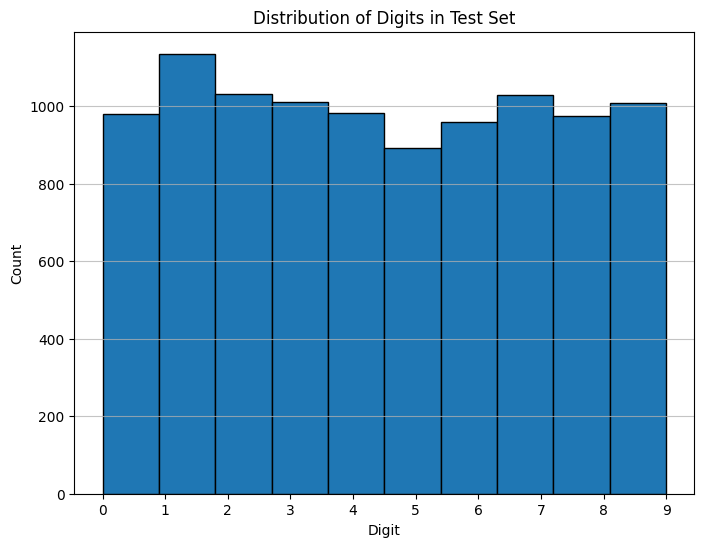

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.hist(test_labels, edgecolor='black')
plt.xticks(range(10))
plt.xlabel('Digit')
plt.ylabel('Count')
plt.title('Distribution of Digits in Test Set')
plt.grid(axis='y', alpha=0.75)
plt.savefig('../output/digit_distribution.png', dpi=150)
plt.show()


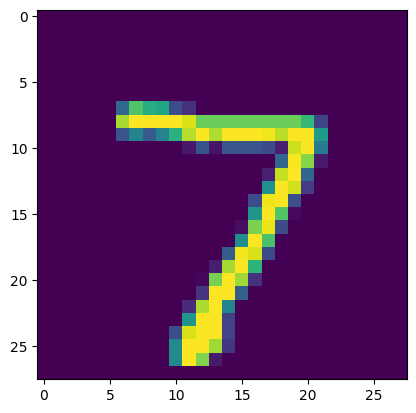

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(test_images[0,0])
plt.show()

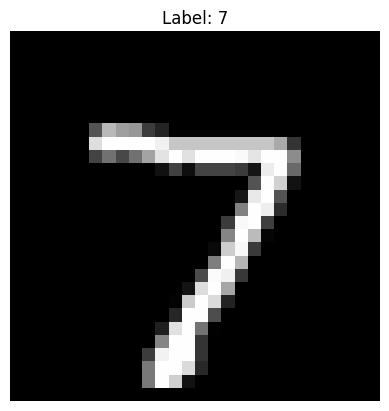

In [10]:
import matplotlib.pyplot as plt

plt.imshow(test_images[0, 0], cmap='gray')
plt.title(f"Label: {test_labels[0]}")
plt.axis('off')
plt.savefig(f'../output/sample_image_label_{test_labels[0]}.png', dpi=150)
plt.show()


(10000, 1, 28, 28)


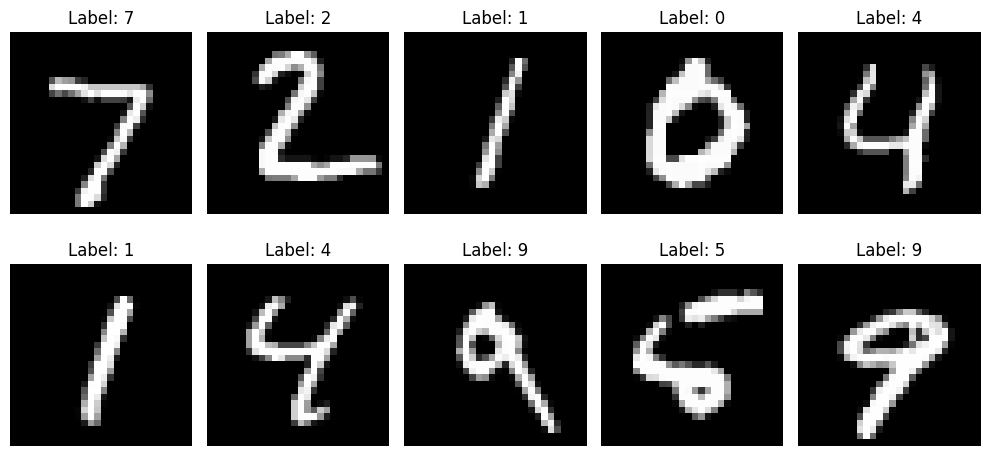

In [11]:
import matplotlib.pyplot as plt

print(test_images.shape)   

# test_images' shape is (N, 1, 28, 28)
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    img = test_images[i, 0] if test_images.ndim == 4 else test_images[i]
    img_display = (img - img.min()) / (img.max() - img.min())
    ax.imshow(img_display, cmap='gray')
    ax.set_title(f"Label: {test_labels[i]}")
    ax.axis('off')
plt.tight_layout()
plt.savefig('../output/sample_images.png', dpi=150)
plt.show()

# Modeling 
Definingn a Convolutional neural network (cnn)

In [12]:
test_images_cnn = test_images.reshape((-1, 28, 28, 1))
print(test_images_cnn.shape)

(10000, 28, 28, 1)


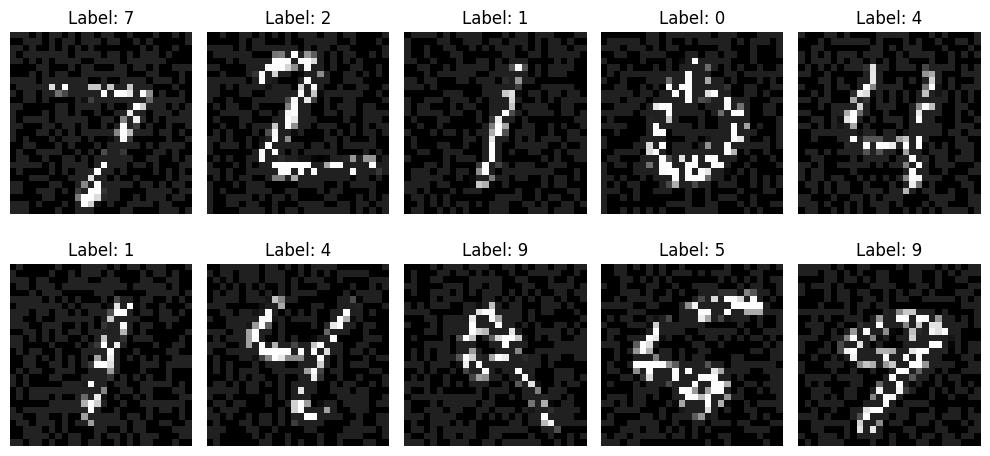

In [13]:
drop_prob = 0.5
drop_mask = np.random.rand(*test_images_cnn.shape) > drop_prob
test_images_dropped = test_images_cnn * drop_mask
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    img = test_images_dropped[i, :, :, 0]
    img_display = (img - img.min()) / (img.max() - img.min())
    plt.imshow(img_display, cmap='gray')
    plt.title(f"Label: {test_labels[i]}")
    plt.axis('off')
plt.tight_layout()
plt.savefig('../output/sample_images_dropped.png', dpi=150)
plt.show()


In [14]:
from tensorflow.keras import layers, models

drop_prob = 0.5
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(drop_prob),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(drop_prob),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(drop_prob),
    layers.Dense(10, activation='softmax')
])  
model.summary()


/workspace/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [16]:
epochs = 10
batch_size = 200
learn_rate = 0.001

fit_model = model.fit(
    test_images_cnn,
    test_labels,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1,
    validation_split = 0.2
    )

print(f"Final training accuracy: {fit_model.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {fit_model.history['val_accuracy'][-1]:.4f}")
print(f"Final training loss: {fit_model.history['loss'][-1]:.4f}")
print(f"Final validation loss: {fit_model.history['val_loss'][-1]:.4f}")

Epoch 1/10


2026-06-22 09:08:52.526648: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 25088000 exceeds 10% of free system memory.


 2/40 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.0838 - loss: 2.9209  

2026-06-22 09:08:52.996367: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 17305600 exceeds 10% of free system memory.
2026-06-22 09:08:53.026067: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 17981568 exceeds 10% of free system memory.
2026-06-22 09:08:53.028348: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 17981568 exceeds 10% of free system memory.
2026-06-22 09:08:53.055833: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 17305600 exceeds 10% of free system memory.


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.3961 - loss: 1.7526 - val_accuracy: 0.8410 - val_loss: 0.7983
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7206 - loss: 0.8277 - val_accuracy: 0.9390 - val_loss: 0.3298
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8340 - loss: 0.5193 - val_accuracy: 0.9560 - val_loss: 0.1981
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8823 - loss: 0.3791 - val_accuracy: 0.9715 - val_loss: 0.1301
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9043 - loss: 0.2941 - val_accuracy: 0.9735 - val_loss: 0.1012
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9141 - loss: 0.2690 - val_accuracy: 0.9780 - val_loss: 0.0876
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9274 - loss: 0.2243 - val_accuracy: 0.9800 - val_loss: 0.0771
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9402 - loss: 0.1903 - val_accuracy: 0.9840 - val_loss: 0.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


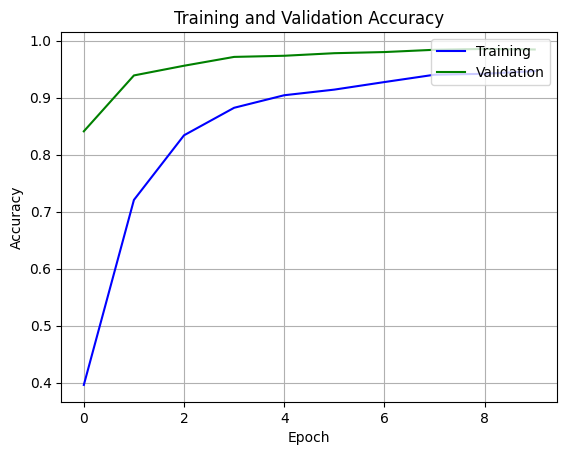

In [17]:
import matplotlib.pyplot as plt

_ = model.predict(test_images_cnn[:1])

plt.plot(fit_model.history['accuracy'], c="b", label='Train Accuracy')
plt.plot(fit_model.history['val_accuracy'], c="g", label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.savefig('../output/accuracy_plot.png', dpi=150)
plt.show()

# Evaluation

In [18]:
ACC = model.evaluate(test_images_cnn, test_labels, verbose=0)
print(f"Test accuracy: {ACC[1]:.4f}")


Test accuracy: 0.9829
